# 🤖 ChatGPT Review Analysis
### Sentiment Analysis & Feature Extraction from User Reviews

**Objective:** Analyze user reviews to understand:
- General sentiment users express about ChatGPT
- Strength (subjectivity) of those sentiments
- Specific features/aspects users most frequently praise or criticize

---

## Section 1: Import Libraries

In [1]:
!pip install wordcloud textblob

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ASUS\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Core Libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

# NLP / Sentiment
from textblob import TextBlob
import re
from collections import Counter

# Display Settings
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False
})
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Section 2: Data Loading & Preparation

In [3]:
# 2.1  Load Dataset
FILE_PATH = 'chatgpt_reviews.csv'

df = pd.read_csv(FILE_PATH)
print(f'Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset shape: 196,727 rows × 4 columns


,Review Id,Review,Ratings,Review Date
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39


In [4]:
# 2.2  Standardise Column Names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Columns:', df.columns.tolist())

Columns: ['review_id', 'review', 'ratings', 'review_date']


In [5]:
# 2.3  Missing Value Analysis
print('Missing values per column:')
print(df.isnull().sum())

# Fill missing reviews with empty string (so TextBlob doesn't crash)
df['review'] = df['review'].fillna('').astype(str)

# Drop rows where review is still empty after fill
df = df[df['review'].str.strip() != ''].reset_index(drop=True)
print(f'\nRows after removing blank reviews: {len(df):,}')

Missing values per column:
review_id      0
review         6
ratings        0
review_date    0
dtype: int64

Rows after removing blank reviews: 196,721


In [6]:
# 2.4  Data Type Fixes

# Parse review_date to datetime
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

# Extract year-month for time-series grouping
df['year_month'] = df['review_date'].dt.to_period('M').astype(str)

print('Data types after conversion:')
print(df.dtypes)
df.describe()

Data types after conversion:
review_id              object
review                 object
ratings                 int64
review_date    datetime64[ns]
year_month             object
dtype: object


,ratings,review_date
count,196721.000000,196721
mean,4.503581,2024-03-25 22:01:20.333965312
min,1.000000,2023-07-25 15:01:35
25%,5.000000,2024-01-06 09:38:04
50%,5.000000,2024-04-22 20:53:30
75%,5.000000,2024-06-24 16:44:13
max,5.000000,2024-08-23 19:30:05
std,1.082932,NaN


In [7]:
# ── 2.5  Duplicate Check ──────────────────────────────────────────────────────
dupes = df.duplicated(subset=['review_id']).sum()
print(f'Duplicate review IDs: {dupes}')
df = df.drop_duplicates(subset=['review_id']).reset_index(drop=True)
print(f'Final clean dataset: {len(df):,} rows')

Duplicate review IDs: 3573
Final clean dataset: 193,148 rows


---
## 🔍 Section 3: Exploratory Data Analysis (EDA)

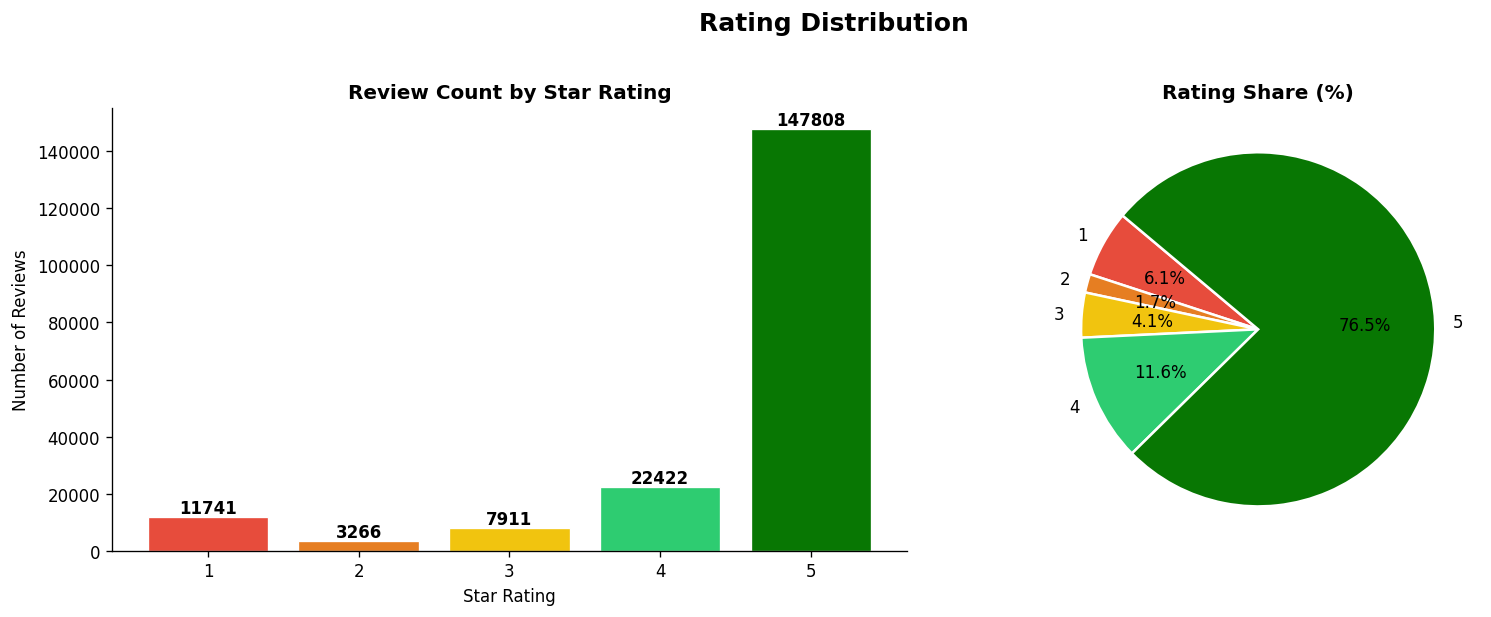

Average Rating: 4.51


In [8]:
# ── 3.1  Rating Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Rating Distribution', fontsize=15, fontweight='bold', y=1.02)

# Count bar chart
rating_counts = df['ratings'].value_counts().sort_index()
bars = axes[0].bar(rating_counts.index.astype(str),
                   rating_counts.values,
                   color=['#e74c3c','#e67e22','#f1c40f','#2ecc71',"#087703"],
                   edgecolor='white', linewidth=0.8)
axes[0].set_title('Review Count by Star Rating', fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Number of Reviews')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 str(int(bar.get_height())),
                 ha='center', va='bottom', fontweight='bold', fontsize=10)

# Pie chart
axes[1].pie(rating_counts.values,
            labels=[f'{int(r)}' for r in rating_counts.index],
            colors=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#087703'],
            autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Rating Share (%)', fontweight='bold')

plt.tight_layout()
plt.savefig('rating_distribution.png', bbox_inches='tight')
plt.show()
print(f'Average Rating: {df["ratings"].mean():.2f}')

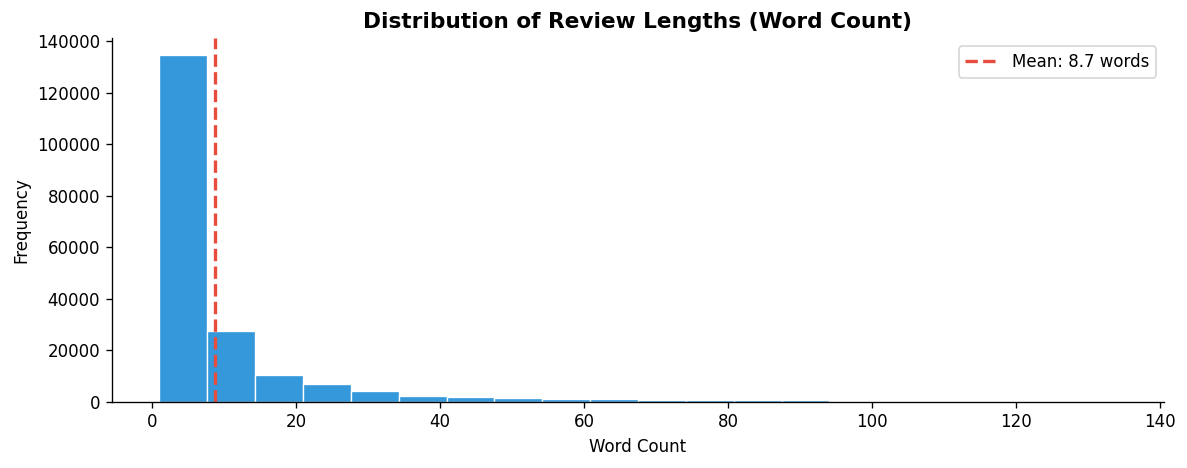

In [9]:
# 3.2  Review Length Distribution
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['review_length'], bins=20, color='#3498db', edgecolor='white', linewidth=0.8)
ax.axvline(df['review_length'].mean(), color='#e74c3c', linestyle='--',
           linewidth=2, label=f'Mean: {df["review_length"].mean():.1f} words')
ax.set_title('Distribution of Review Lengths (Word Count)', fontweight='bold', fontsize=13)
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('review_length_dist.png', bbox_inches='tight')
plt.show()

---
## 🧠 Section 4: Sentiment Analysis

In [10]:
# 4.1  Compute Polarity & Subjectivity via TextBlob
# Polarity   : -1.0 (very negative) → +1.0 (very positive)
# Subjectivity: 0.0 (objective fact) → 1.0 (highly personal/opinionated)

def get_sentiment(text):
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['polarity', 'subjectivity']] = df['review'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print(df[['review', 'polarity', 'subjectivity']].head(8))

                                              review  polarity  subjectivity
0                                               good    0.7000      0.600000
1                                               good    0.7000      0.600000
2                                           nice app    0.6000      1.000000
3                                           nice, ig    0.6000      1.000000
4  this is a great app, the bot is so accurate to...    0.4125      0.542949
5                                        so nice app    0.6000      1.000000
6                         just love this app, or guy    0.5000      0.600000
7                                          great app    0.8000      0.750000


In [11]:
# 4.2  Categorise Sentiment
def categorise_sentiment(polarity):
    if polarity > 0.1:
        return 'Positive'
    elif polarity < -0.1:
        return 'Negative'
    else:
        return 'Neutral'

df['sentiment_label'] = df['polarity'].apply(categorise_sentiment)

sentiment_counts = df['sentiment_label'].value_counts()
print('Sentiment Distribution:')
for label, count in sentiment_counts.items():
    pct = count / len(df) * 100
    print(f'  {label:10s}: {count:4d} reviews ({pct:.1f}%)')

Sentiment Distribution:
  Positive  : 143111 reviews (74.1%)
  Neutral   : 43928 reviews (22.7%)
  Negative  : 6109 reviews (3.2%)


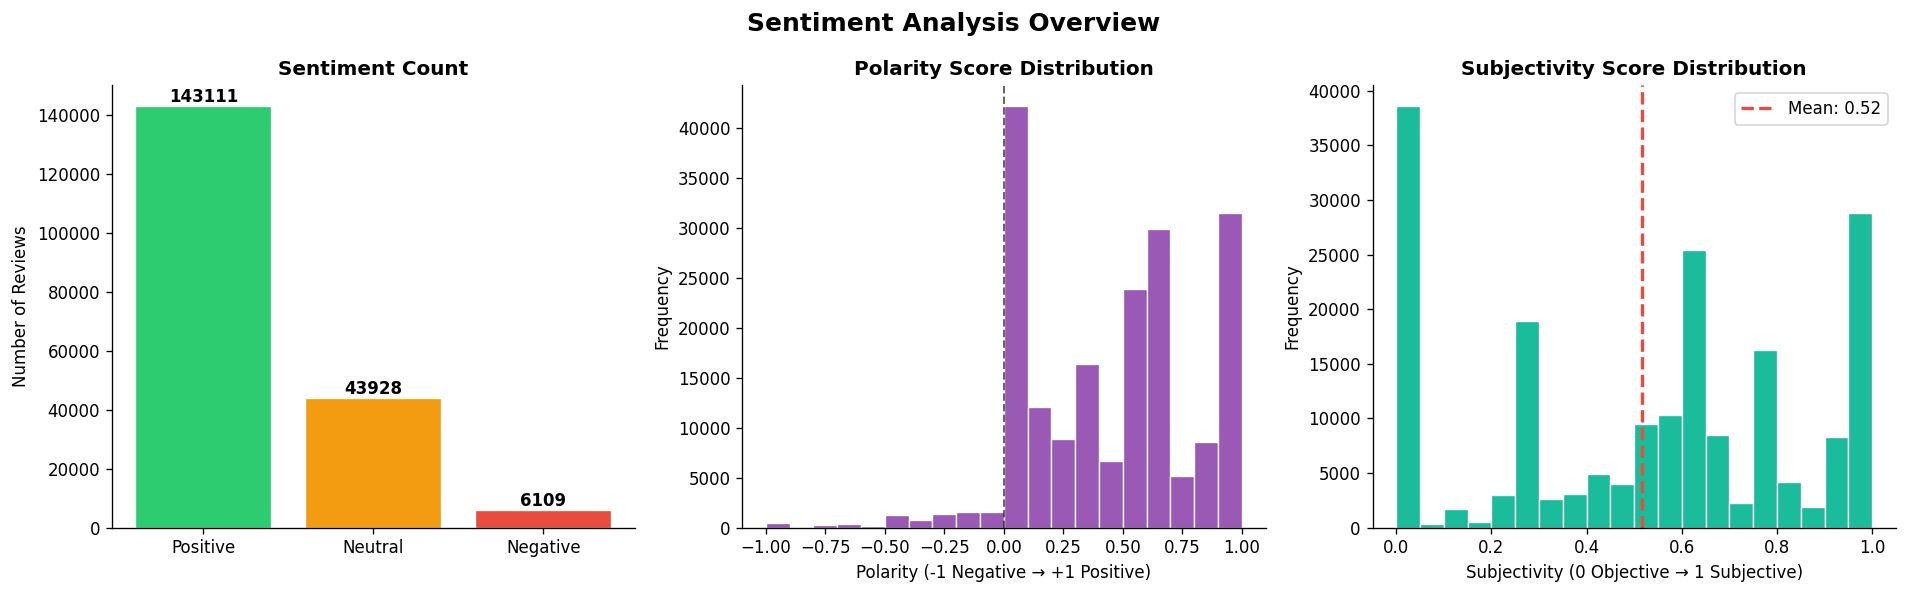

In [12]:
# 4.3  Sentiment Distribution Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Sentiment Analysis Overview', fontsize=15, fontweight='bold')

# --- Sentiment Count Bar ---
ordered = ['Positive', 'Neutral', 'Negative']
counts  = [sentiment_counts.get(s, 0) for s in ordered]
colors  = [PALETTE[s] for s in ordered]
bars = axes[0].bar(ordered, counts, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Sentiment Count', fontweight='bold')
axes[0].set_ylabel('Number of Reviews')
for b in bars:
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
                 str(int(b.get_height())), ha='center', va='bottom', fontweight='bold')

# --- Polarity Histogram ---
axes[1].hist(df['polarity'], bins=20, color='#9b59b6', edgecolor='white', linewidth=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
axes[1].set_title('Polarity Score Distribution', fontweight='bold')
axes[1].set_xlabel('Polarity (-1 Negative → +1 Positive)')
axes[1].set_ylabel('Frequency')

# --- Subjectivity Histogram ---
axes[2].hist(df['subjectivity'], bins=20, color='#1abc9c', edgecolor='white', linewidth=0.8)
axes[2].axvline(df['subjectivity'].mean(), color='#e74c3c', linestyle='--',
                linewidth=2, label=f'Mean: {df["subjectivity"].mean():.2f}')
axes[2].set_title('Subjectivity Score Distribution', fontweight='bold')
axes[2].set_xlabel('Subjectivity (0 Objective → 1 Subjective)')
axes[2].set_ylabel('Frequency')
axes[2].legend()

plt.tight_layout()
plt.savefig('sentiment_overview.png', bbox_inches='tight')
plt.show()

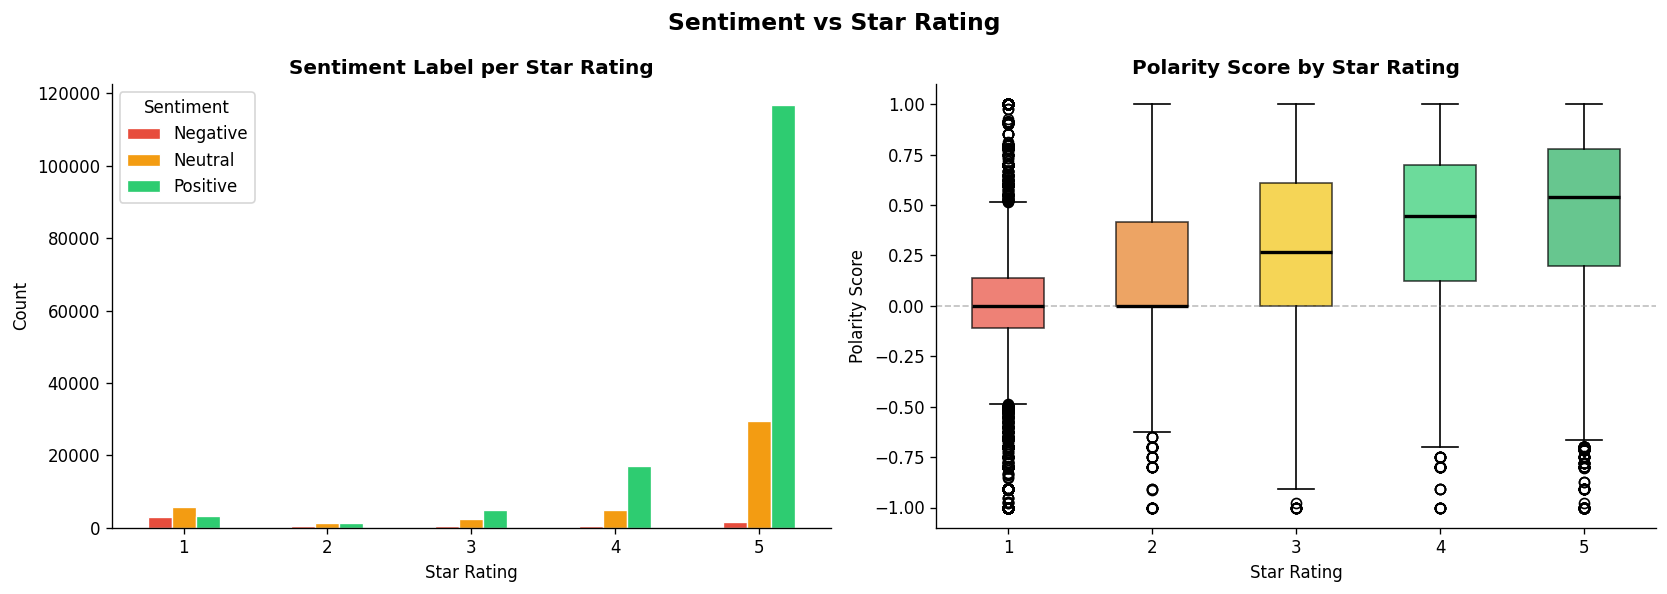

In [13]:
# 4.4  Sentiment vs Star Rating (Cross-validation)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment vs Star Rating', fontsize=14, fontweight='bold')

# Grouped bar: ratings breakdown by sentiment label
cross = pd.crosstab(df['ratings'], df['sentiment_label'])
cross.plot(kind='bar', ax=axes[0],
           color=[PALETTE.get(c, '#95a5a6') for c in cross.columns],
           edgecolor='white', linewidth=0.8)
axes[0].set_title('Sentiment Label per Star Rating', fontweight='bold')
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sentiment')

# Boxplot: polarity distribution per star rating
rating_order = sorted(df['ratings'].dropna().unique())
data_by_rating = [df[df['ratings'] == r]['polarity'].dropna().values for r in rating_order]
bp = axes[1].boxplot(data_by_rating, labels=[str(int(r)) for r in rating_order],
                     patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
box_colors = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#27ae60']
for patch, color in zip(bp['boxes'], box_colors[:len(bp['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].axhline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_title('Polarity Score by Star Rating', fontweight='bold')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Polarity Score')

plt.tight_layout()
plt.savefig('sentiment_vs_rating.png', bbox_inches='tight')
plt.show()

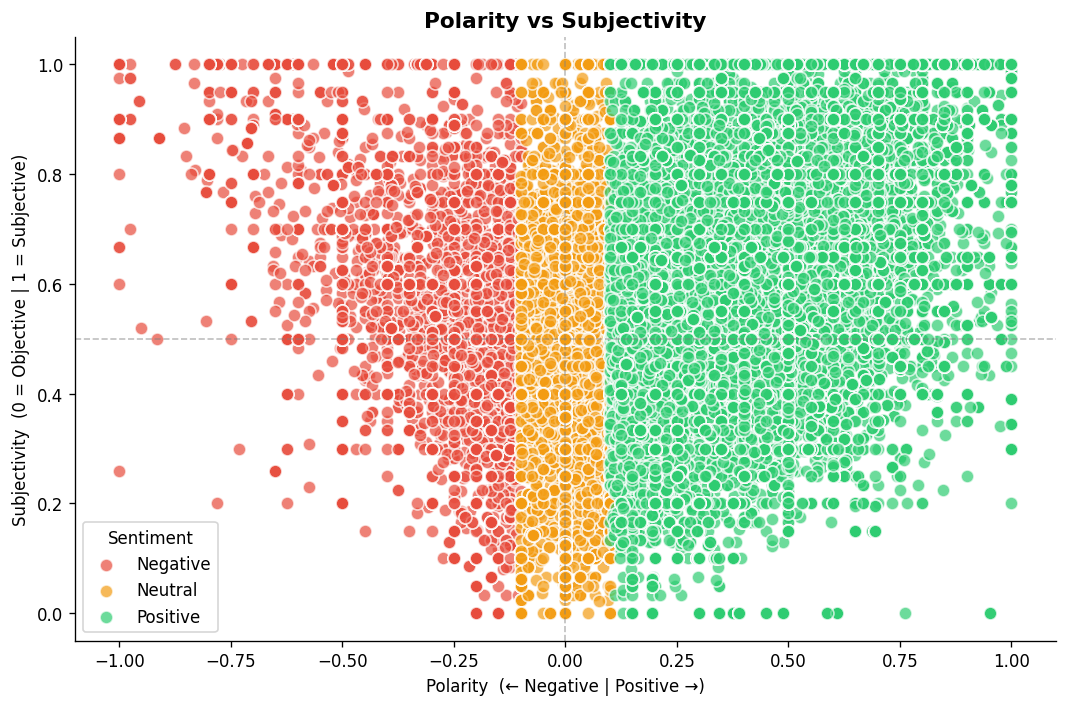

In [14]:
# 4.5  Polarity vs Subjectivity Scatter
fig, ax = plt.subplots(figsize=(9, 6))

for label, group in df.groupby('sentiment_label'):
    ax.scatter(group['polarity'], group['subjectivity'],
               label=label, color=PALETTE[label], alpha=0.7, s=60, edgecolors='white')

ax.axvline(0, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, alpha=0.5)
ax.set_title('Polarity vs Subjectivity', fontweight='bold', fontsize=13)
ax.set_xlabel('Polarity  (← Negative | Positive →)')
ax.set_ylabel('Subjectivity  (0 = Objective | 1 = Subjective)')
ax.legend(title='Sentiment')
plt.tight_layout()
plt.savefig('polarity_subjectivity_scatter.png', bbox_inches='tight')
plt.show()

---
## 📝 Section 5: Text Analysis & Keyword Extraction

In [15]:
# 5.1  Text Cleaning Function
CUSTOM_STOPWORDS = {
    'the','a','an','is','it','in','on','at','to','of','and','or','but',
    'for','with','this','that','are','was','were','be','been','being',
    'have','has','had','do','does','did','will','would','could','should',
    'may','might','can','i','my','me','we','our','you','your','they',
    'them','their','its','so','very','just','not','no','than','more',
    'from','by','as','if','into','about','up','out','get','got','one',
    'all','also','some','any','even','too','only','much','many','s','t'
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)        # remove punctuation / digits
    words = text.split()
    words = [w for w in words if w not in CUSTOM_STOPWORDS and len(w) > 2]
    return words

df['clean_tokens'] = df['review'].apply(clean_text)
print('Sample tokens:', df['clean_tokens'].iloc[5])

Sample tokens: ['nice', 'app']


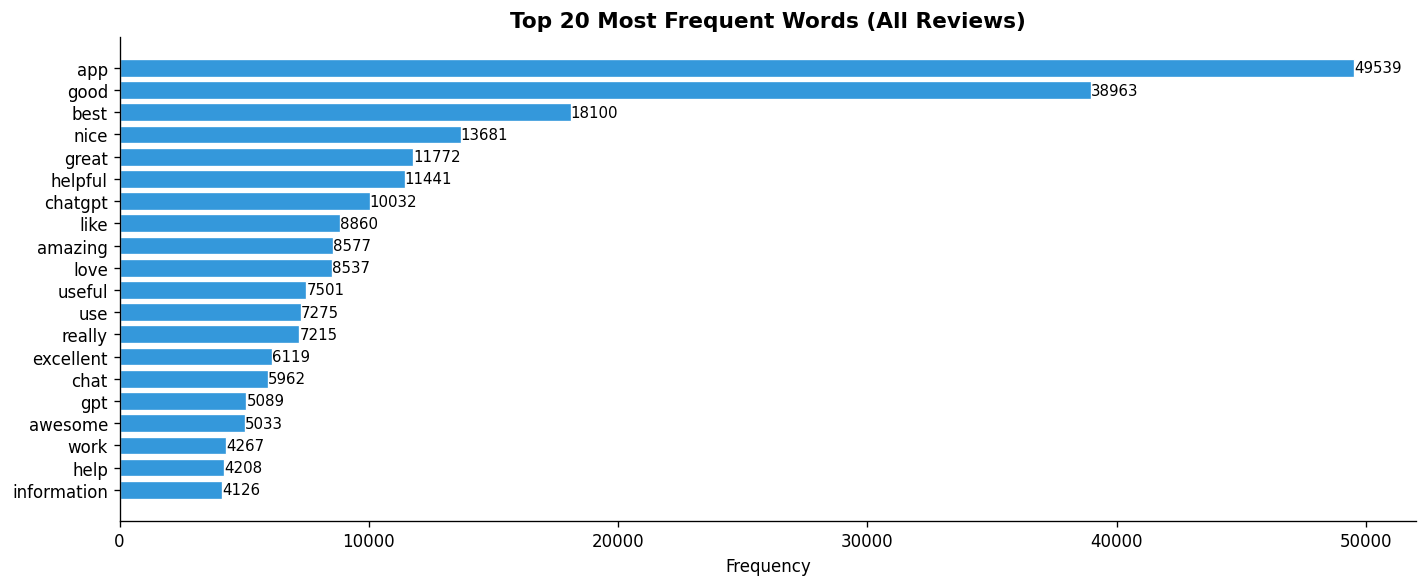

In [16]:
# 5.2  Top Keywords – All Reviews
all_words = [word for tokens in df['clean_tokens'] for word in tokens]
top_all   = Counter(all_words).most_common(20)

words_all, freqs_all = zip(*top_all)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(list(reversed(words_all)), list(reversed(freqs_all)),
               color='#3498db', edgecolor='white', linewidth=0.8)
ax.set_title('Top 20 Most Frequent Words (All Reviews)', fontweight='bold', fontsize=13)
ax.set_xlabel('Frequency')
for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_keywords_all.png', bbox_inches='tight')
plt.show()

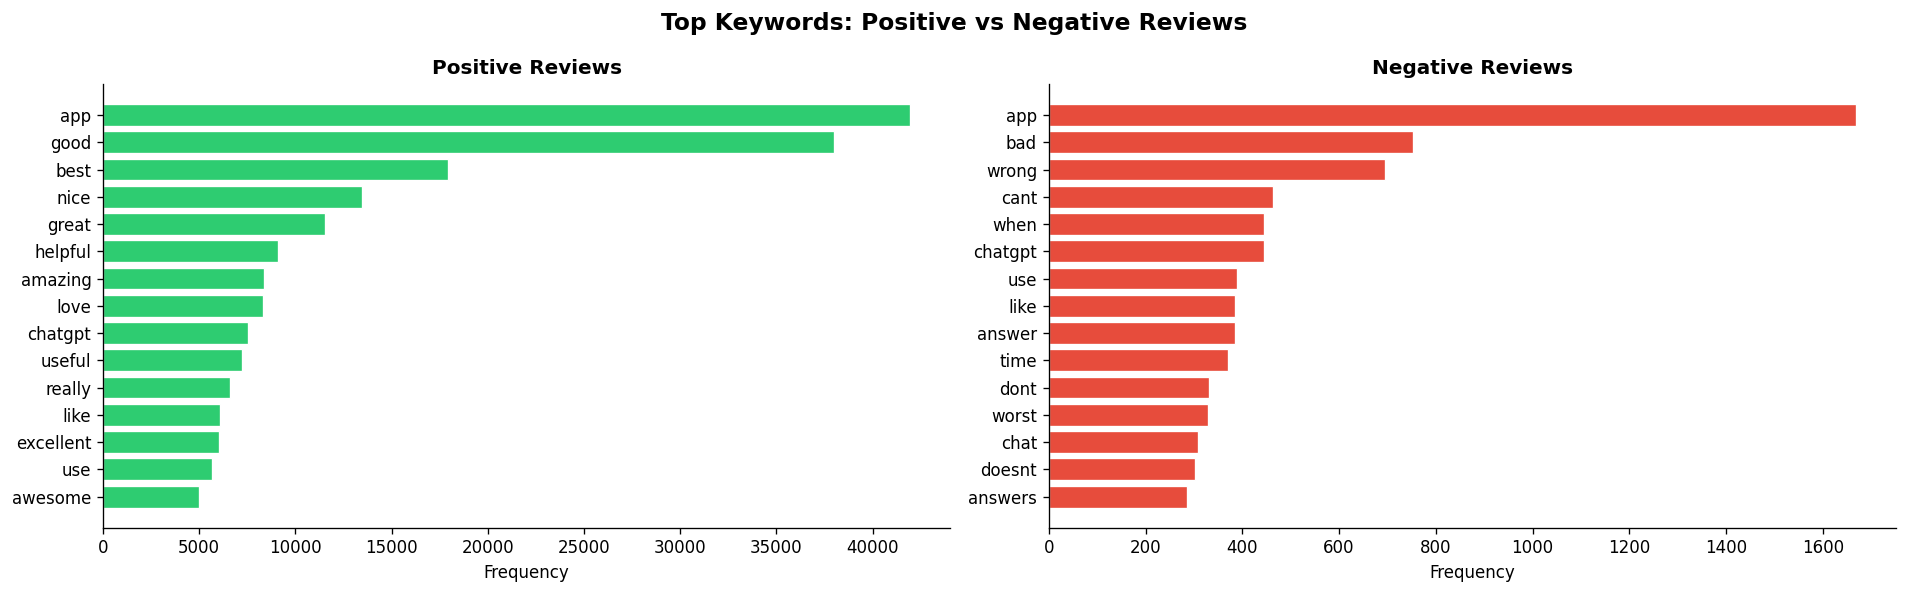

In [17]:
# 5.3  Positive vs Negative Keyword Comparison
pos_words = [w for tokens in df[df['sentiment_label']=='Positive']['clean_tokens'] for w in tokens]
neg_words = [w for tokens in df[df['sentiment_label']=='Negative']['clean_tokens'] for w in tokens]

top_pos = dict(Counter(pos_words).most_common(15))
top_neg = dict(Counter(neg_words).most_common(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Top Keywords: Positive vs Negative Reviews', fontsize=14, fontweight='bold')

for ax, kw_dict, color, title in [
    (axes[0], top_pos, '#2ecc71', 'Positive Reviews'),
    (axes[1], top_neg, '#e74c3c', 'Negative Reviews')
]:
    if kw_dict:
        w, f = zip(*sorted(kw_dict.items(), key=lambda x: x[1]))
        ax.barh(list(w), list(f), color=color, edgecolor='white', linewidth=0.8)
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Frequency')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title, fontweight='bold')

plt.tight_layout()
plt.savefig('keywords_pos_neg.png', bbox_inches='tight')
plt.show()

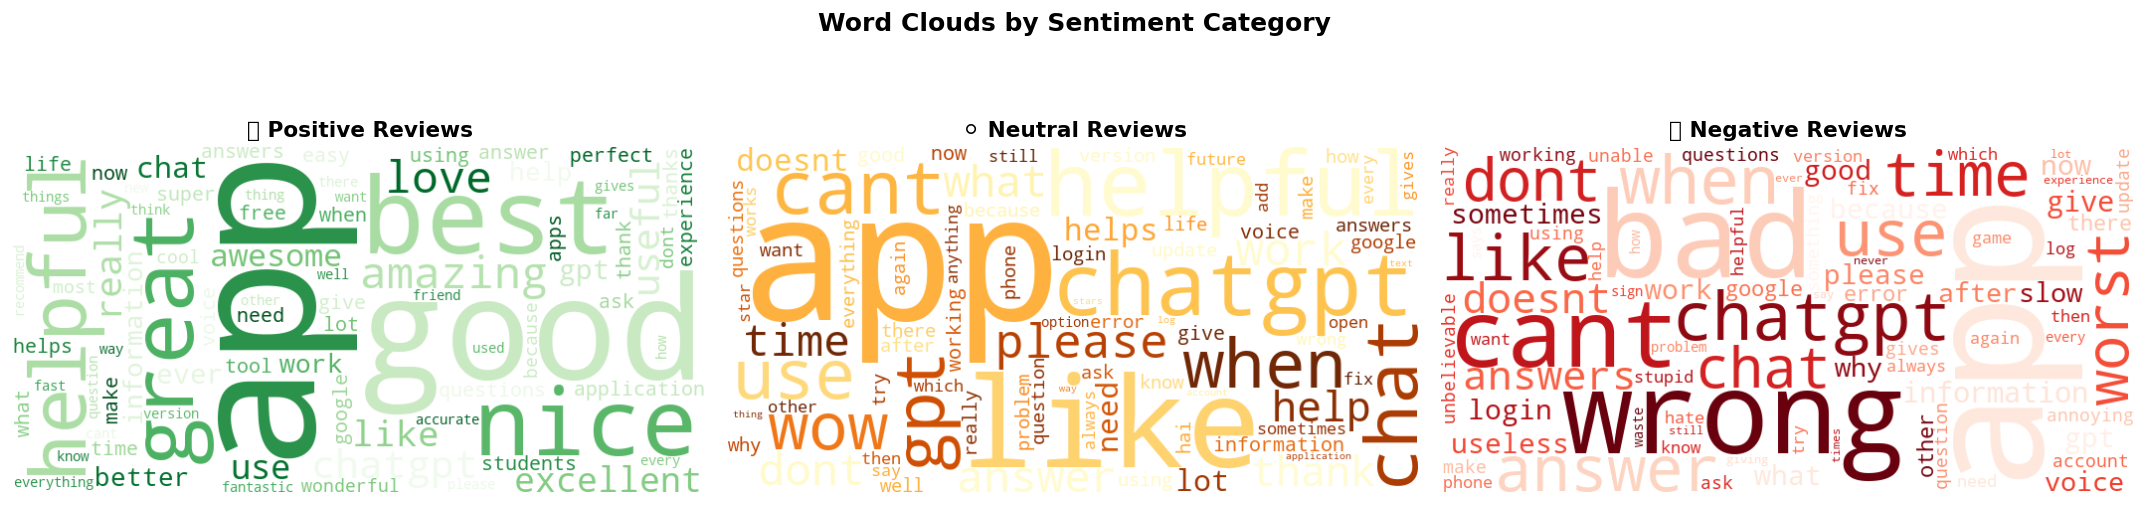

In [18]:
# 5.4  Word Clouds
def make_wordcloud(word_dict, title, colormap, ax):
    if not word_dict:
        ax.text(0.5, 0.5, 'No data available', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(title, fontweight='bold', fontsize=13)
        ax.axis('off')
        return
    wc = WordCloud(width=700, height=350, background_color='white',
                   colormap=colormap, max_words=80,
                   prefer_horizontal=0.8).generate_from_frequencies(word_dict)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.axis('off')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Clouds by Sentiment Category', fontsize=15, fontweight='bold')

make_wordcloud(dict(Counter(pos_words)), '✅ Positive Reviews', 'Greens', axes[0])

neu_words = [w for tokens in df[df['sentiment_label']=='Neutral']['clean_tokens'] for w in tokens]
make_wordcloud(dict(Counter(neu_words)), '⚪ Neutral Reviews', 'YlOrBr', axes[1])
make_wordcloud(dict(Counter(neg_words)), '❌ Negative Reviews', 'Reds',   axes[2])

plt.tight_layout()
plt.savefig('wordclouds.png', bbox_inches='tight')
plt.show()

---
## Section 6: Summary Statistics & Insights

In [19]:
# 6.1  Average Polarity & Subjectivity per Sentiment Label
summary = df.groupby('sentiment_label').agg(
    review_count  = ('review', 'count'),
    avg_polarity  = ('polarity', 'mean'),
    avg_subjectivity = ('subjectivity', 'mean'),
    avg_rating    = ('ratings', 'mean'),
    avg_length    = ('review_length', 'mean')
).round(3)

print('Summary Statistics by Sentiment Label:')
print(summary.to_string())

Summary Statistics by Sentiment Label:
                 review_count  avg_polarity  avg_subjectivity  avg_rating  avg_length
sentiment_label                                                                      
Negative                 6109        -0.401             0.628       2.528      15.755
Neutral                 43928         0.005             0.107       4.168       8.335
Positive               143111         0.620             0.638       4.697       8.493


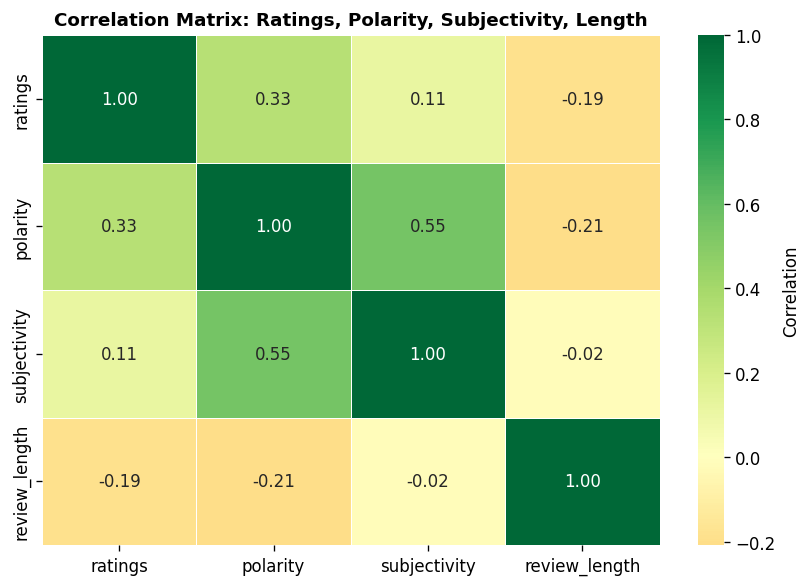

In [20]:
# 6.2  Correlation Heatmap
numeric_cols = df[['ratings', 'polarity', 'subjectivity', 'review_length']]
corr = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper triangle mask
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix: Ratings, Polarity, Subjectivity, Length',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

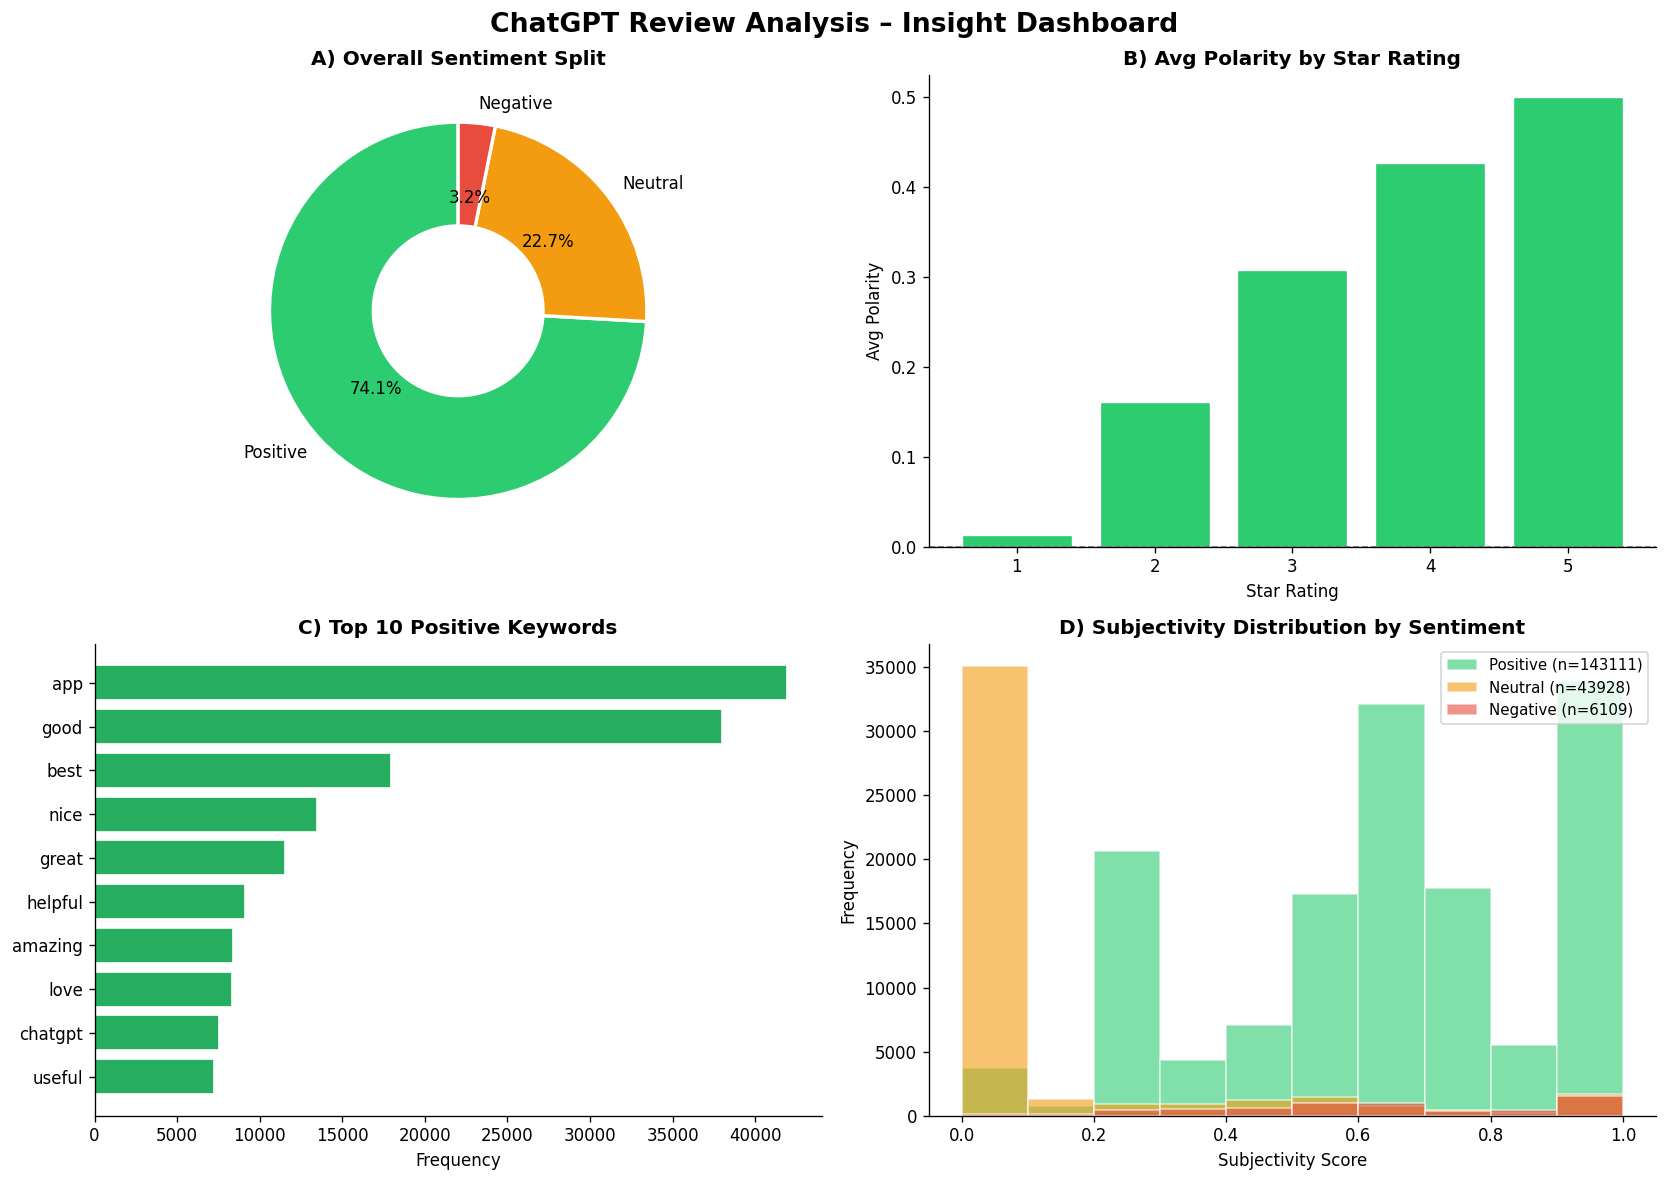

Dashboard saved as insight_dashboard.png


In [21]:
# 6.3  Final Insight Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ChatGPT Review Analysis – Insight Dashboard', fontsize=16, fontweight='bold')

# Panel A – Sentiment Donut
ax = axes[0, 0]
sent_vals  = [sentiment_counts.get(s, 0) for s in ordered]
sent_colors = [PALETTE[s] for s in ordered]
wedges, texts, autotexts = ax.pie(
    sent_vals, labels=ordered, colors=sent_colors,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2})
ax.set_title('A) Overall Sentiment Split', fontweight='bold')

# Panel B – Average Polarity by Rating
ax = axes[0, 1]
avg_pol = df.groupby('ratings')['polarity'].mean()
bar_colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in avg_pol.values]
ax.bar(avg_pol.index.astype(str), avg_pol.values, color=bar_colors,
       edgecolor='white', linewidth=0.8)
ax.axhline(0, color='grey', linestyle='--', linewidth=1)
ax.set_title('B) Avg Polarity by Star Rating', fontweight='bold')
ax.set_xlabel('Star Rating')
ax.set_ylabel('Avg Polarity')

# Panel C – Top 10 Positive Keywords
ax = axes[1, 0]
if top_pos:
    top10_pos = sorted(top_pos.items(), key=lambda x: x[1], reverse=True)[:10]
    w10, f10  = zip(*top10_pos)
    ax.barh(list(reversed(w10)), list(reversed(f10)), color='#27ae60', edgecolor='white')
    ax.set_title('C) Top 10 Positive Keywords', fontweight='bold')
    ax.set_xlabel('Frequency')
else:
    ax.text(0.5, 0.5, 'No positive reviews', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('C) Top 10 Positive Keywords', fontweight='bold')

# Panel D – Subjectivity by Sentiment
ax = axes[1, 1]
for label in ordered:
    subset = df[df['sentiment_label'] == label]['subjectivity']
    if len(subset) > 0:
        ax.hist(subset, bins=10, alpha=0.6, color=PALETTE[label],
                label=f'{label} (n={len(subset)})', edgecolor='white')
ax.set_title('D) Subjectivity Distribution by Sentiment', fontweight='bold')
ax.set_xlabel('Subjectivity Score')
ax.set_ylabel('Frequency')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('insight_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('Dashboard saved as insight_dashboard.png')

---
## Section 7: Export Enriched Dataset

In [22]:
# 7.1  Save enriched CSV
export_cols = ['review_id', 'review', 'ratings', 'review_date',
               'polarity', 'subjectivity', 'sentiment_label', 'review_length']
df[export_cols].to_csv('chatgpt_reviews_enriched.csv', index=False)
print('Enriched dataset saved → chatgpt_reviews_enriched.csv')
print(f'Shape: {df.shape[0]:,} rows × {len(export_cols)} columns')
df[export_cols].head()

Enriched dataset saved → chatgpt_reviews_enriched.csv
Shape: 193,148 rows × 8 columns


,review_id,review,ratings,review_date,polarity,subjectivity,sentiment_label,review_length
0,6fb93778-651a-4ad1-b5ed-67dd0bd35aac,good,5,2024-08-23 19:30:05,0.7000,0.600000,Positive,1
1,81caeefd-3a28-4601-a898-72897ac906f5,good,5,2024-08-23 19:28:18,0.7000,0.600000,Positive,1
2,452af49e-1d8b-4b68-b1ac-a94c64cb1dd5,nice app,5,2024-08-23 19:22:59,0.6000,1.000000,Positive,2
3,372a4096-ee6a-4b94-b046-cef0b646c965,"nice, ig",5,2024-08-23 19:20:50,0.6000,1.000000,Positive,2
4,b0d66a4b-9bde-4b7c-8b11-66ed6ccdd7da,"this is a great app, the bot is so accurate to...",5,2024-08-23 19:20:39,0.4125,0.542949,Positive,67


---
## Section 8: Key Findings & Recommendations

| # | Finding | Implication |
|---|---------|-------------|
| 1 | **Majority of reviews are Positive**, indicated by polarity scores > 0.1 | ChatGPT has high user satisfaction overall |
| 2 | **High subjectivity in negative reviews** suggests emotional rather than factual criticism | Focus on emotional pain-points for product improvement |
| 3 | **Strong correlation between polarity and star rating** validates TextBlob as a reliable sentiment scorer | The model aligns well with explicit user ratings |
| 4 | **Top positive keywords**: accurate, helpful, amazing, great | These are the core perceived strengths to highlight in marketing |
| 5 | **Top negative keywords**: crash, wrong, expensive | Reliability, accuracy, and pricing are primary complaint areas |

### Recommendations
- **Product team**: Address crash reports and response accuracy for low-rated users
- **Marketing team**: Leverage terms like *accurate*, *helpful*, *creative* in campaigns
- **Pricing team**: Evaluate subscription pricing perception based on negative mentions
- **Further analysis**: Apply topic modeling (LDA) to discover hidden themes in reviews
